# 🥗 Diet Optimization Using Linear & Nonlinear Programming
### ARTI-309 & MATH-403 — Final Project
**Objective:** Minimize daily caloric intake while satisfying all nutritional requirements

---


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linprog, minimize
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'figure.dpi'       : 130,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

COLORS = ['#2E86AB','#A23B72','#F18F01','#C73E1D','#44BBA4',
          '#E94F37','#393E41','#F5A623','#7B2D8B','#3B1F2B',
          '#1D7874','#EE4266','#FFD23F','#3BCEAC','#0EAD69']

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load & Explore the Dataset

In [2]:
df_raw = pd.read_csv('food.csv')

print(f"Dataset shape     : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Food categories   : {df_raw['Category'].nunique():,}")
print(f"\nAvailable nutrient columns:")
for col in df_raw.columns:
    if col.startswith('Data'):
        print(f"   {col}")


Dataset shape     : 7,083 rows × 38 columns
Food categories   : 2,429

Available nutrient columns:
   Data.Alpha Carotene
   Data.Beta Carotene
   Data.Beta Cryptoxanthin
   Data.Carbohydrate
   Data.Cholesterol
   Data.Choline
   Data.Fiber
   Data.Lutein and Zeaxanthin
   Data.Lycopene
   Data.Niacin
   Data.Protein
   Data.Retinol
   Data.Riboflavin
   Data.Selenium
   Data.Sugar Total
   Data.Thiamin
   Data.Water
   Data.Fat.Monosaturated Fat
   Data.Fat.Polysaturated Fat
   Data.Fat.Saturated Fat
   Data.Fat.Total Lipid
   Data.Major Minerals.Calcium
   Data.Major Minerals.Copper
   Data.Major Minerals.Iron
   Data.Major Minerals.Magnesium
   Data.Major Minerals.Phosphorus
   Data.Major Minerals.Potassium
   Data.Major Minerals.Sodium
   Data.Major Minerals.Zinc
   Data.Vitamins.Vitamin A - RAE
   Data.Vitamins.Vitamin B12
   Data.Vitamins.Vitamin B6
   Data.Vitamins.Vitamin C
   Data.Vitamins.Vitamin E
   Data.Vitamins.Vitamin K


In [3]:
df_raw.head(3)


,Category,Description,Nutrient Data Bank Number,Data.Alpha Carotene,Data.Beta Carotene,Data.Beta Cryptoxanthin,Data.Carbohydrate,Data.Cholesterol,Data.Choline,Data.Fiber,...,Data.Major Minerals.Phosphorus,Data.Major Minerals.Potassium,Data.Major Minerals.Sodium,Data.Major Minerals.Zinc,Data.Vitamins.Vitamin A - RAE,Data.Vitamins.Vitamin B12,Data.Vitamins.Vitamin B6,Data.Vitamins.Vitamin C,Data.Vitamins.Vitamin E,Data.Vitamins.Vitamin K
0,Milk,"Milk, human",11000000,0,7,0,6.89,14,16.0,0.0,...,14,51,17,0.17,61,0.05,0.011,5.0,0.08,0.3
1,Milk,"Milk, NFS",11100000,0,4,0,4.87,8,17.9,0.0,...,103,157,39,0.42,59,0.56,0.060,0.1,0.03,0.2
2,Milk,"Milk, whole",11111000,0,7,0,4.67,12,17.8,0.0,...,101,150,38,0.41,32,0.54,0.061,0.0,0.05,0.3


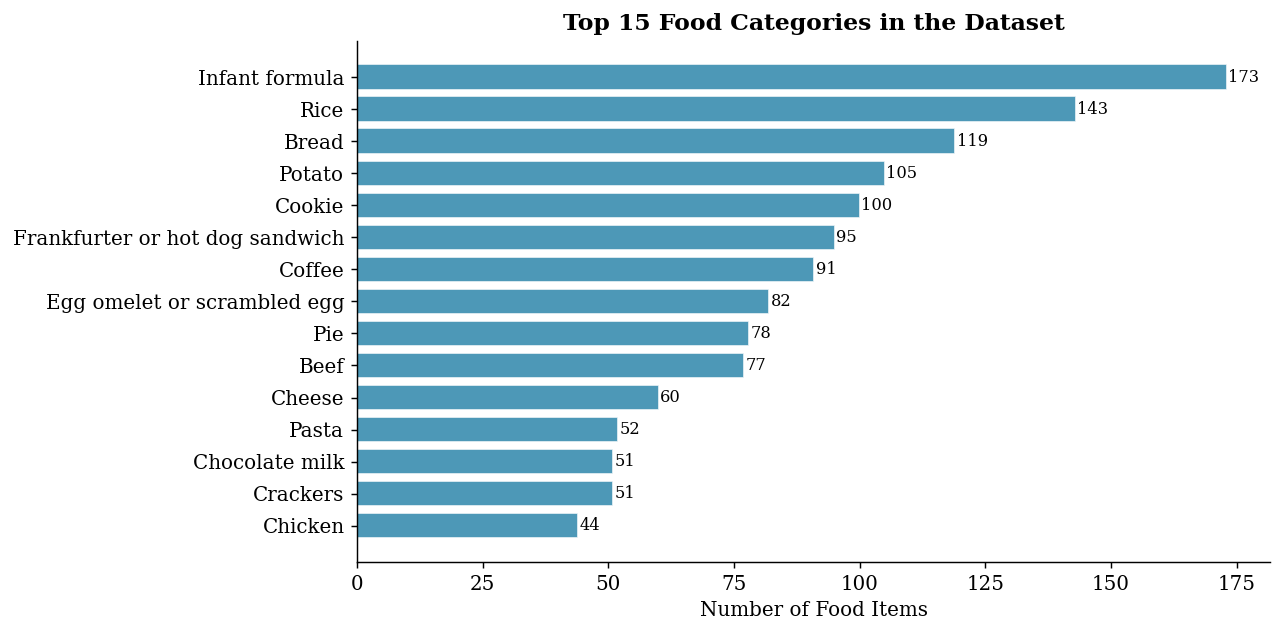

In [4]:
# Top 15 categories by number of food items
top_cats = df_raw['Category'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_cats.index[::-1], top_cats.values[::-1],
               color='#2E86AB', alpha=0.85, edgecolor='white')
for bar, val in zip(bars, top_cats.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
ax.set_xlabel('Number of Food Items')
ax.set_title('Top 15 Food Categories in the Dataset')
plt.tight_layout()
plt.savefig('figure1_category_distribution.png', bbox_inches='tight')
plt.show()


## 3. Data Preparation

### Computing Calories
The dataset does not contain a calorie column. We compute it using the
standard **Atwater general factors** — the same method used by the USDA:

$$\text{Calories} = 4 \times \text{Protein (g)} + 9 \times \text{Fat (g)} + 4 \times \text{Carbohydrate (g)}$$

These coefficients reflect the energy density of each macronutrient per gram.

### Food Selection
We select 20 representative food items from common categories to keep
the optimization interpretable while covering a wide nutritional range.


In [5]:
# Compute calories from macronutrients (Atwater formula)
df_raw['Calories'] = (
    4 * df_raw['Data.Protein'] +
    9 * df_raw['Data.Fat.Total Lipid'] +
    4 * df_raw['Data.Carbohydrate']
)

print('Calories computed: 4*Protein + 9*Fat + 4*Carbs')
print('Range: {:.1f} - {:.1f} kcal per 100g'.format(df_raw['Calories'].min(), df_raw['Calories'].max()))

# Select foods using EXACT category names from the dataset
category_map = {
    'Chicken'      : 'Chicken breast',
    'Egg'          : 'Egg',
    'Milk'         : 'Milk',
    'Rice'         : 'Rice',
    'Broccoli'     : 'Broccoli',
    'Spinach'      : 'Spinach',
    'Banana'       : 'Banana',
    'Apple'        : 'Apple',
    'Oats'         : 'Oats',
    'Tuna'         : 'Tuna',
    'Lentils'      : 'Lentils',
    'Bread'        : 'Bread',
    'Peanut Butter': 'Peanut butter',
    'Orange'       : 'Orange',
    'Sweet Potato' : 'Sweet potato',
    'Yogurt'       : 'Yogurt',
    'Almonds'      : 'Almonds',
    'Carrots'      : 'Carrots',
    'Salmon'       : 'Salmon',
    'Beef'         : 'Beef',
}

selected_rows = []
for label, cat in category_map.items():
    match = df_raw[df_raw['Category'] == cat]
    if not match.empty:
        row = match.iloc[0].copy()
        row['Food'] = label
        selected_rows.append(row)
        print('  {:20s} -> {:30s} | {}'.format(label, cat, str(row['Description'])[:45]))
    else:
        print('  {:20s} -> NOT FOUND'.format(label))

df = pd.DataFrame(selected_rows).reset_index(drop=True)
print('\nTotal foods selected: {}'.format(len(df)))

Calories computed: 4*Protein + 9*Fat + 4*Carbs
Range: 0.0 - 900.3 kcal per 100g
  Chicken              -> Chicken breast                 | Chicken breast, NS as to cooking method, skin
  Egg                  -> Egg                            | Egg, whole, raw
  Milk                 -> Milk                           | Milk, human
  Rice                 -> Rice                           | Rice, cooked, NFS
  Broccoli             -> Broccoli                       | Broccoli, raw
  Spinach              -> Spinach                        | Spinach, raw
  Banana               -> Banana                         | Banana, raw
  Apple                -> Apple                          | Apple, dried
  Oats                 -> Oats                           | Oats, raw
  Tuna                 -> Tuna                           | Tuna, fresh, raw
  Lentils              -> Lentils                        | Lentils, NFS
  Bread                -> Bread                          | Bread, NS as to major flour


In [6]:
# ── Define nutrients used in the model ──
nutrient_cols = {
    'Data.Protein'                 : 'Protein (g)',
    'Data.Fat.Total Lipid'         : 'Fat (g)',
    'Data.Carbohydrate'            : 'Carbs (g)',
    'Data.Fiber'                   : 'Fiber (g)',
    'Data.Major Minerals.Calcium'  : 'Calcium (mg)',
    'Data.Major Minerals.Iron'     : 'Iron (mg)',
    'Data.Vitamins.Vitamin C'      : 'Vitamin C (mg)',
    'Data.Major Minerals.Potassium': 'Potassium (mg)',
}

df_model = df[['Food', 'Category', 'Calories'] + list(nutrient_cols.keys())].copy()
df_model.rename(columns=nutrient_cols, inplace=True)

nutrient_names = list(nutrient_cols.values())
req_units      = ['g', 'g', 'g', 'g', 'mg', 'mg', 'mg', 'mg']

print("Final dataset for optimization:")
df_model[['Food', 'Calories'] + nutrient_names]


Final dataset for optimization:


,Food,Calories,Protein (g),Fat (g),Carbs (g),Fiber (g),Calcium (mg),Iron (mg),Vitamin C (mg),Potassium (mg)
0,Chicken,174.87,26.37,7.67,0.09,0.0,16,0.51,0.0,276
1,Egg,138.71,12.56,9.51,0.72,0.0,56,1.75,0.0,138
2,Milk,71.10,1.03,4.38,6.89,0.0,32,0.03,5.0,51
3,Rice,125.16,2.67,0.28,27.99,0.4,10,1.19,0.0,35
4,Broccoli,41.17,2.82,0.37,6.64,2.6,47,0.73,89.2,316
5,Spinach,29.47,2.86,0.39,3.63,2.2,99,2.71,28.1,558
6,Banana,98.69,1.09,0.33,22.84,2.6,5,0.26,8.7,358
7,Apple,270.16,0.93,0.32,65.89,8.7,14,1.40,3.9,450
8,Oats,382.08,13.15,6.52,67.70,10.1,52,4.25,0.0,362
9,Tuna,102.01,24.40,0.49,0.00,0.0,4,0.77,0.0,441


## 4. Exploratory Data Analysis (EDA)

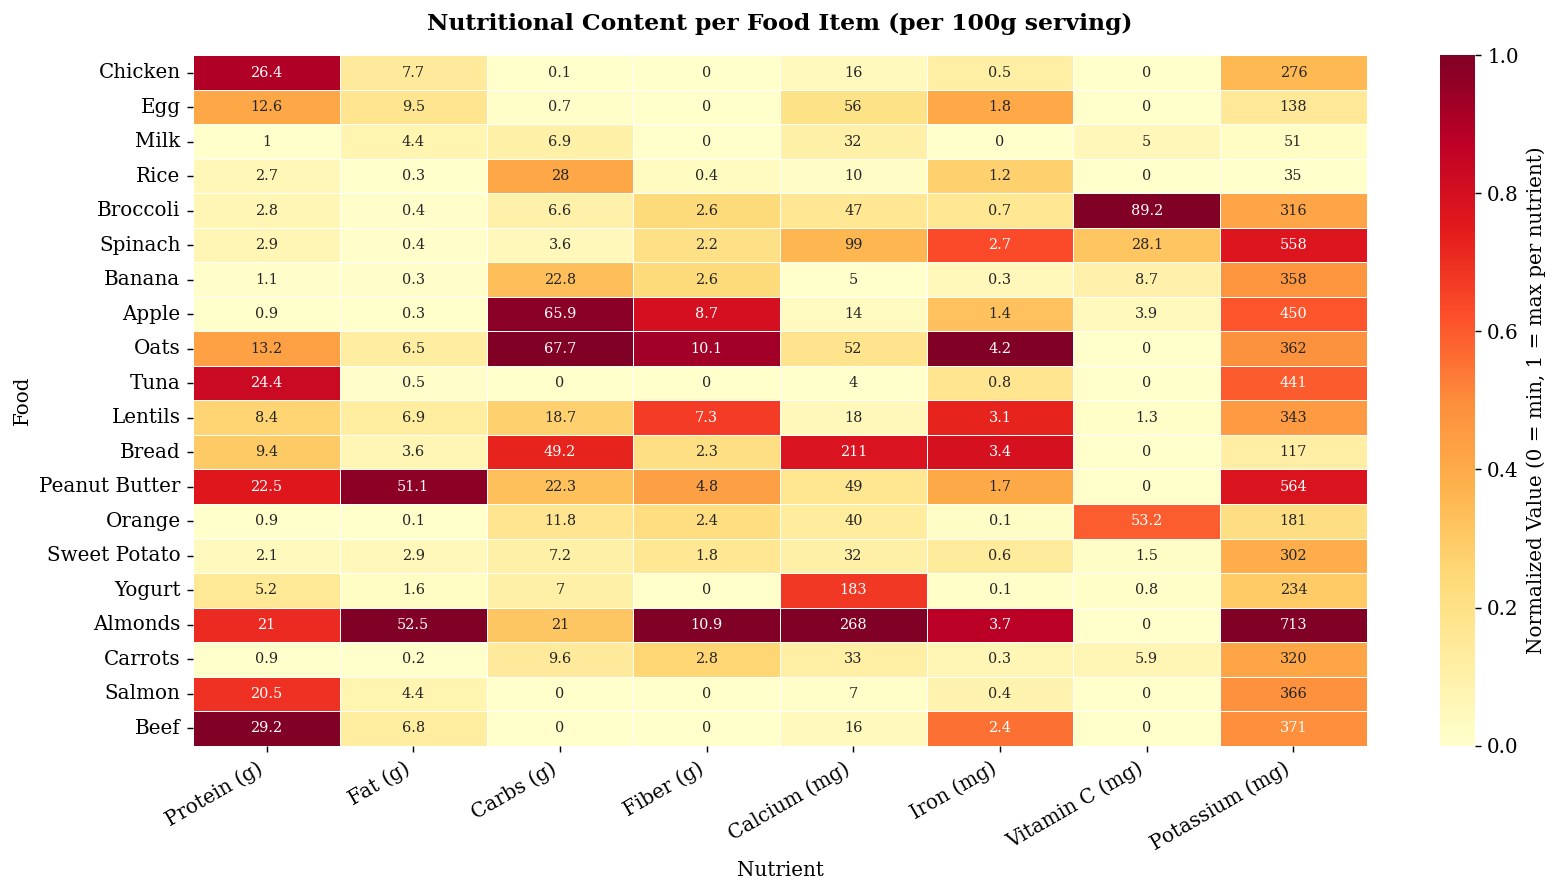

Darker cells indicate higher relative content for that nutrient.


In [7]:
# ── Heatmap: normalized nutrient content per food ──
fig, ax = plt.subplots(figsize=(13, 7))

matrix      = df_model[nutrient_names].astype(float)
matrix_norm = (matrix - matrix.min()) / (matrix.max() - matrix.min() + 1e-9)

sns.heatmap(
    matrix_norm.set_index(df_model['Food']),
    annot=matrix.round(1).values,
    fmt='g',
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Normalized Value (0 = min, 1 = max per nutrient)'},
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Nutritional Content per Food Item (per 100g serving)', pad=14)
ax.set_xlabel('Nutrient')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('figure2_nutrition_heatmap.png', bbox_inches='tight')
plt.show()
print("Darker cells indicate higher relative content for that nutrient.")


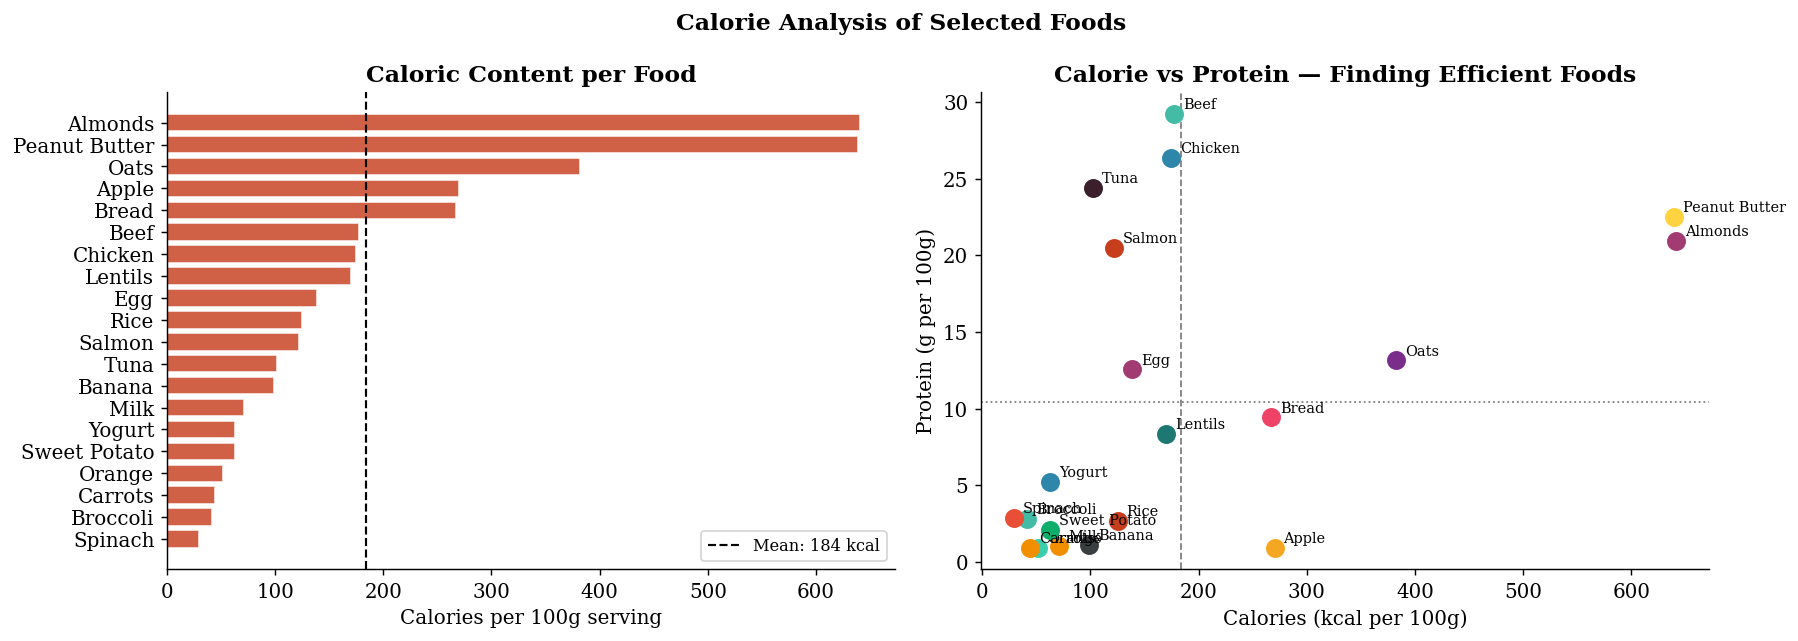

Foods in the bottom-left quadrant (low calorie, decent protein) are ideal LP candidates.


In [8]:
# ── Calorie content per food (our objective variable) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: calories per food
cal_order = df_model.sort_values('Calories', ascending=True)
axes[0].barh(cal_order['Food'], cal_order['Calories'],
             color='#C73E1D', alpha=0.82, edgecolor='white')
axes[0].axvline(df_model['Calories'].mean(), color='black',
                linestyle='--', linewidth=1.2, label=f"Mean: {df_model['Calories'].mean():.0f} kcal")
axes[0].set_xlabel('Calories per 100g serving')
axes[0].set_title('Caloric Content per Food')
axes[0].legend(fontsize=9)

# Scatter: calories vs protein (efficiency view)
for i, row in df_model.iterrows():
    axes[1].scatter(row['Calories'], row['Protein (g)'],
                    color=COLORS[i % len(COLORS)], s=90, zorder=3)
    axes[1].annotate(row['Food'], (row['Calories'], row['Protein (g)']),
                     textcoords='offset points', xytext=(5, 3), fontsize=8)

axes[1].axvline(df_model['Calories'].mean(), color='gray', linestyle='--', linewidth=1)
axes[1].axhline(df_model['Protein (g)'].mean(), color='gray', linestyle=':', linewidth=1)
axes[1].set_xlabel('Calories (kcal per 100g)')
axes[1].set_ylabel('Protein (g per 100g)')
axes[1].set_title('Calorie vs Protein — Finding Efficient Foods')

plt.suptitle('Calorie Analysis of Selected Foods', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figure3_calorie_analysis.png', bbox_inches='tight')
plt.show()
print("Foods in the bottom-left quadrant (low calorie, decent protein) are ideal LP candidates.")


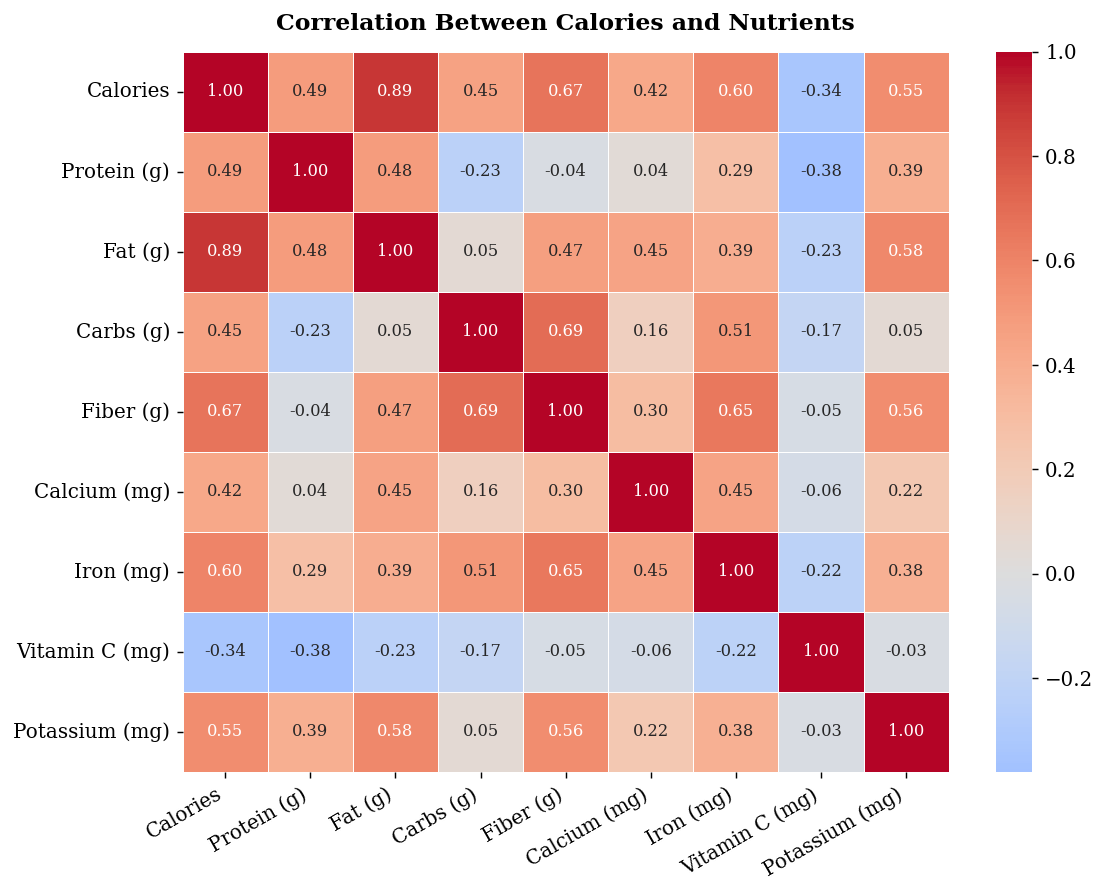

Strong positive correlation with Fat (as expected — fat has the highest energy density at 9 kcal/g).


In [9]:
# ── Correlation heatmap between nutrients ──
fig, ax = plt.subplots(figsize=(9, 7))

corr = df_model[['Calories'] + nutrient_names].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, linecolor='white',
            ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Between Calories and Nutrients', pad=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('figure4_correlation.png', bbox_inches='tight')
plt.show()
print("Strong positive correlation with Fat (as expected — fat has the highest energy density at 9 kcal/g).")


## 5. Problem Formulation

### Decision Variables
Let $x_i$ = number of 100g servings of food $i$ consumed per day, $i = 1, 2, \ldots, n$

### Objective Function (Linear)
**Minimize** total daily caloric intake:

$$\text{Minimize } Z = \sum_{i=1}^{n} \text{Cal}_i \cdot x_i$$

where $\text{Cal}_i$ is the calorie content per 100g serving of food $i$ (computed via Atwater formula).

### Constraints — Daily Nutritional Minimums
$$\sum_{i=1}^{n} a_{ij} \cdot x_i \geq b_j \quad \forall j$$

| Nutrient | Min. Daily Requirement | Unit | Source |
|---|---|---|---|
| Protein | 50 | g | WHO/DRI |
| Fat | 44 | g | DRI |
| Carbohydrates | 225 | g | DRI |
| Fiber | 25 | g | DRI |
| Calcium | 1000 | mg | DRI |
| Iron | 8 | mg | DRI |
| Vitamin C | 60 | mg | DRI |
| Potassium | 3500 | mg | DRI |

### Bounds
$$0 \leq x_i \leq 10 \quad \forall i \quad \text{(0 to 10 servings × 100g per food)}$$


In [10]:
# ── Build LP/NLP inputs from dataset ──

# Objective: calorie vector (what we minimize)
cal_vec = df_model['Calories'].values.astype(float)

# Nutrient matrix A: shape (n_foods × n_nutrients)
A = df_model[nutrient_names].values.astype(float)

# Daily minimum requirements (same order as nutrient_names)
b = np.array([
    50,    # Protein (g)
    44,    # Fat (g)
    225,   # Carbs (g)
    25,    # Fiber (g)
    1000,  # Calcium (mg)
    8,     # Iron (mg)
    60,    # Vitamin C (mg)
    3500,  # Potassium (mg)
])

n_foods     = len(df_model)
n_nutrients = len(nutrient_names)
bounds      = [(0, 10)] * n_foods

print(f"Decision variables (foods)     : {n_foods}")
print(f"Constraints (nutrients)        : {n_nutrients}")
print(f"Objective vector (calories)    : {cal_vec.round(1)}")
print(f"Nutrient matrix A shape        : {A.shape}")
print(f"Requirements vector b          : {b}")


Decision variables (foods)     : 20
Constraints (nutrients)        : 8
Objective vector (calories)    : [174.9 138.7  71.1 125.2  41.2  29.5  98.7 270.2 382.1 102.  170.1 266.8
 639.1  51.8  62.9  63.1 640.7  44.2 121.6 177.7]
Nutrient matrix A shape        : (20, 8)
Requirements vector b          : [  50   44  225   25 1000    8   60 3500]


## 6. Linear Programming (LP)

We use `scipy.optimize.linprog` with the **HiGHS** solver (Simplex method).

**Standard form conversion:**
`linprog` requires $A_{ub} x \leq b_{ub}$, but our constraints are minimums ($Ax \geq b$).
We convert by multiplying both sides by $-1$:

$$-A^T x \leq -b$$


In [11]:
lp_result = linprog(
    c      = cal_vec,     # minimize calories
    A_ub   = -A.T,        # shape (n_nutrients, n_foods), flipped for >= constraints
    b_ub   = -b,
    bounds = bounds,
    method = 'highs'
)

lp_x                  = lp_result.x
lp_calories           = lp_result.fun
lp_nutrients_achieved = A.T @ lp_x

print("=" * 58)
print("LINEAR PROGRAMMING — RESULTS")
print("=" * 58)
print(f"Solver status          : {lp_result.message}")
print(f"Optimal daily calories : {lp_calories:.1f} kcal")

print(f"\n{'Food':<25} {'Servings':>10} {'Cal contribution':>18}")
print("-" * 55)
for food, qty, cal in zip(df_model['Food'], lp_x, cal_vec):
    if qty > 0.001:
        print(f"{food:<25} {qty:>10.3f} {qty*cal:>15.1f} kcal")
print("-" * 55)
print(f"{'TOTAL':>36} {lp_calories:>13.1f} kcal")

print(f"\n{'Nutrient':<20} {'Achieved':>10} {'Required':>10} {'Unit':>6} {'%':>6}")
print("-" * 55)
for nut, ach, req, unit in zip(nutrient_names, lp_nutrients_achieved, b, req_units):
    pct  = ach / req * 100
    flag = '✅' if pct >= 100 else '❌'
    print(f"{flag} {nut:<18} {ach:>10.1f} {req:>10.0f} {unit:>6} {pct:>5.0f}%")


LINEAR PROGRAMMING — RESULTS
Solver status          : Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimal daily calories : 1496.0 kcal

Food                        Servings   Cal contribution
-------------------------------------------------------
Milk                           0.080             5.7 kcal
Spinach                        1.671            49.3 kcal
Banana                         7.629           752.9 kcal
Peanut Butter                  0.666           425.6 kcal
Yogurt                         4.160           262.5 kcal
-------------------------------------------------------
                               TOTAL        1496.0 kcal

Nutrient               Achieved   Required   Unit      %
-------------------------------------------------------
✅ Protein (g)              50.0         50      g   100%
✅ Fat (g)                  44.0         44      g   100%
✅ Carbs (g)               225.0        225      g   100%
✅ Fiber (g)                26.7         25   

## 7. Nonlinear Programming (NLP)

The LP minimizes calories but may produce an extreme diet (only 2–3 foods
eaten in very large quantities). We add a **quadratic penalty** that discourages
large deviations from nutrient targets, resulting in a more balanced diet:

$$\text{Minimize } Z_{NLP} = \underbrace{\sum_{i} \text{Cal}_i \cdot x_i}_{\text{Calorie objective}} + \lambda \underbrace{\sum_{j} \left(\frac{\sum_i a_{ij} x_i - b_j}{b_j}\right)^2}_{\text{Balance penalty}}$$

- $\lambda$ controls the trade-off: higher $\lambda$ = more balanced, higher calories
- All nutrient minimum constraints are still enforced
- Solved using **SLSQP** (Sequential Least Squares Programming)


In [12]:
lambda_ = 0.05   # penalty weight

def nlp_objective(x):
    calories  = np.dot(cal_vec, x)
    achieved  = A.T @ x
    deviation = (achieved - b) / b          # normalized deviation per nutrient
    penalty   = lambda_ * np.sum(deviation ** 2)
    return calories + penalty

def nlp_gradient(x):
    achieved     = A.T @ x
    deviation    = (achieved - b) / b
    cal_grad     = cal_vec
    penalty_grad = lambda_ * 2 * (A @ (deviation / b))
    return cal_grad + penalty_grad

nlp_constraints = [
    {'type': 'ineq', 'fun': lambda x, i=i: (A.T @ x)[i] - b[i]}
    for i in range(n_nutrients)
]

x0 = np.ones(n_foods) * 0.5   # initial guess: 0.5 servings of each food

nlp_result = minimize(
    fun         = nlp_objective,
    x0          = x0,
    jac         = nlp_gradient,
    method      = 'SLSQP',
    bounds      = bounds,
    constraints = nlp_constraints,
    options     = {'ftol': 1e-10, 'maxiter': 2000}
)

nlp_x                  = nlp_result.x
nlp_calories           = np.dot(cal_vec, nlp_x)
nlp_nutrients_achieved = A.T @ nlp_x

print("=" * 58)
print("NONLINEAR PROGRAMMING — RESULTS")
print("=" * 58)
print(f"Solver status          : {nlp_result.message}")
print(f"Optimal daily calories : {nlp_calories:.1f} kcal")

print(f"\n{'Food':<25} {'Servings':>10} {'Cal contribution':>18}")
print("-" * 55)
for food, qty, cal in zip(df_model['Food'], nlp_x, cal_vec):
    if qty > 0.001:
        print(f"{food:<25} {qty:>10.3f} {qty*cal:>15.1f} kcal")
print("-" * 55)
print(f"{'TOTAL':>36} {nlp_calories:>13.1f} kcal")

print(f"\n{'Nutrient':<20} {'Achieved':>10} {'Required':>10} {'Unit':>6} {'%':>6}")
print("-" * 55)
for nut, ach, req, unit in zip(nutrient_names, nlp_nutrients_achieved, b, req_units):
    pct  = ach / req * 100
    flag = '✅' if pct >= 100 else '❌'
    print(f"{flag} {nut:<18} {ach:>10.1f} {req:>10.0f} {unit:>6} {pct:>5.0f}%")


NONLINEAR PROGRAMMING — RESULTS
Solver status          : Positive directional derivative for linesearch
Optimal daily calories : 1496.0 kcal

Food                        Servings   Cal contribution
-------------------------------------------------------
Egg                            0.005             0.8 kcal
Milk                           0.926            65.8 kcal
Rice                           0.101            12.7 kcal
Broccoli                       0.039             1.6 kcal
Spinach                        0.300             8.8 kcal
Banana                         1.540           152.0 kcal
Apple                          1.195           322.9 kcal
Bread                          0.773           206.3 kcal
Peanut Butter                  0.503           321.4 kcal
Orange                         0.220            11.4 kcal
Sweet Potato                   1.314            82.7 kcal
Yogurt                         3.533           223.0 kcal
Carrots                        1.504            66

## 8. Results & Comparison

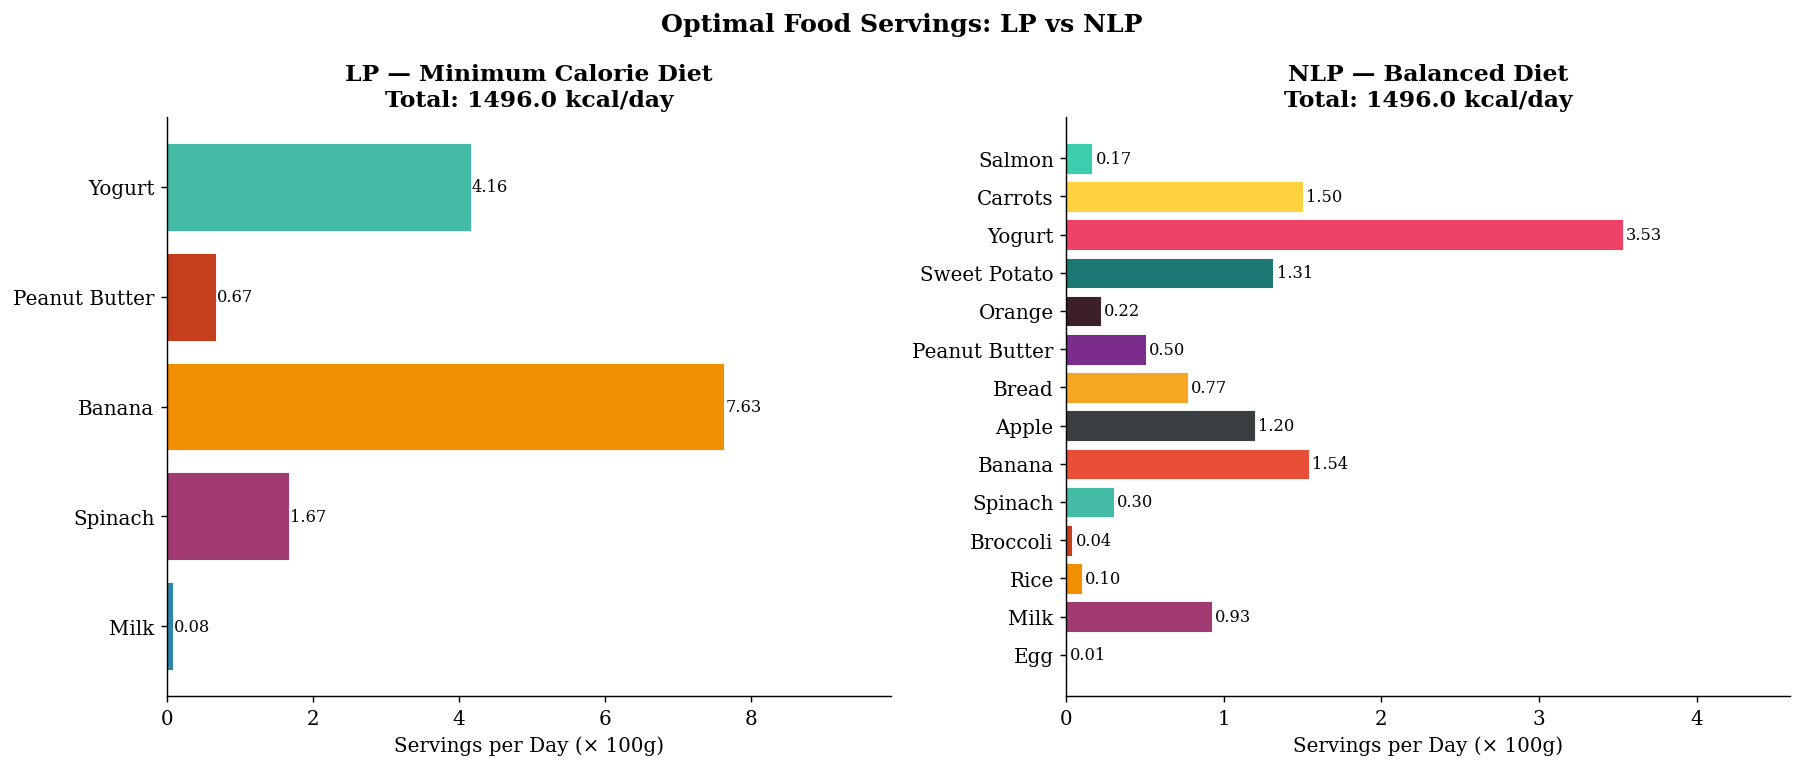

In [13]:
# ── Figure: LP vs NLP optimal servings ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, x_vals, title, total_cal in zip(
    axes,
    [lp_x, nlp_x],
    ['LP — Minimum Calorie Diet', 'NLP — Balanced Diet'],
    [lp_calories, nlp_calories]
):
    mask  = x_vals > 0.001
    foods = df_model['Food'][mask].values
    qty   = x_vals[mask]
    cal_contrib = cal_vec[mask] * qty
    clrs  = [COLORS[i % len(COLORS)] for i in range(len(foods))]
    bars  = ax.barh(foods, qty, color=clrs, edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Servings per Day (× 100g)')
    ax.set_title(f'{title}\nTotal: {total_cal:.1f} kcal/day')
    ax.set_xlim(0, max(qty) * 1.3)
    for bar, val in zip(bars, qty):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=9)

plt.suptitle('Optimal Food Servings: LP vs NLP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figure5_servings_comparison.png', bbox_inches='tight')
plt.show()


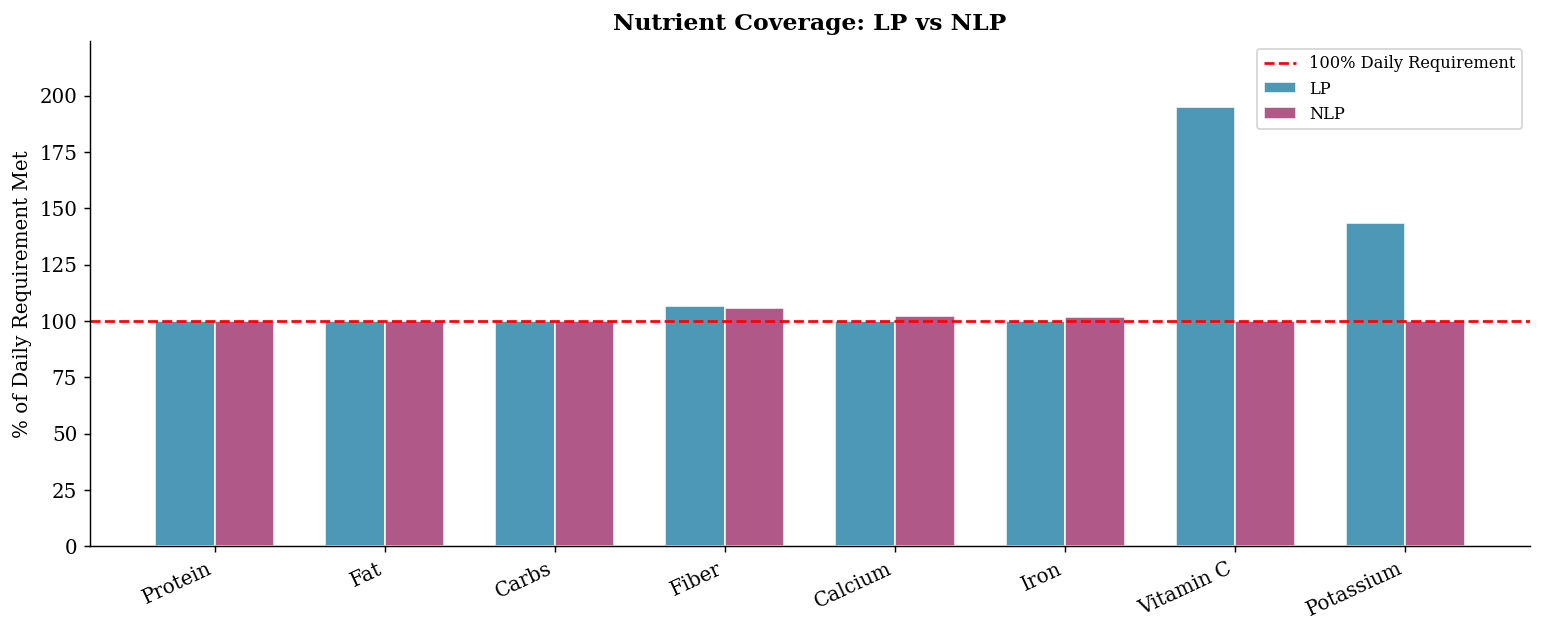

In [14]:
# ── Figure: Nutrient coverage comparison ──
fig, ax = plt.subplots(figsize=(12, 5))

x_pos   = np.arange(n_nutrients)
width   = 0.35
lp_pct  = lp_nutrients_achieved  / b * 100
nlp_pct = nlp_nutrients_achieved / b * 100

b1 = ax.bar(x_pos - width/2, lp_pct,  width, label='LP',  color='#2E86AB', alpha=0.85, edgecolor='white')
b2 = ax.bar(x_pos + width/2, nlp_pct, width, label='NLP', color='#A23B72', alpha=0.85, edgecolor='white')
ax.axhline(100, color='red', linestyle='--', linewidth=1.5, label='100% Daily Requirement')

short_labels = [n.split('(')[0].strip() for n in nutrient_names]
ax.set_xticks(x_pos)
ax.set_xticklabels(short_labels, rotation=25, ha='right')
ax.set_ylabel('% of Daily Requirement Met')
ax.set_title('Nutrient Coverage: LP vs NLP')
ax.legend(fontsize=9)
ax.set_ylim(0, max(lp_pct.max(), nlp_pct.max()) * 1.15)
plt.tight_layout()
plt.savefig('figure6_nutrient_coverage.png', bbox_inches='tight')
plt.show()


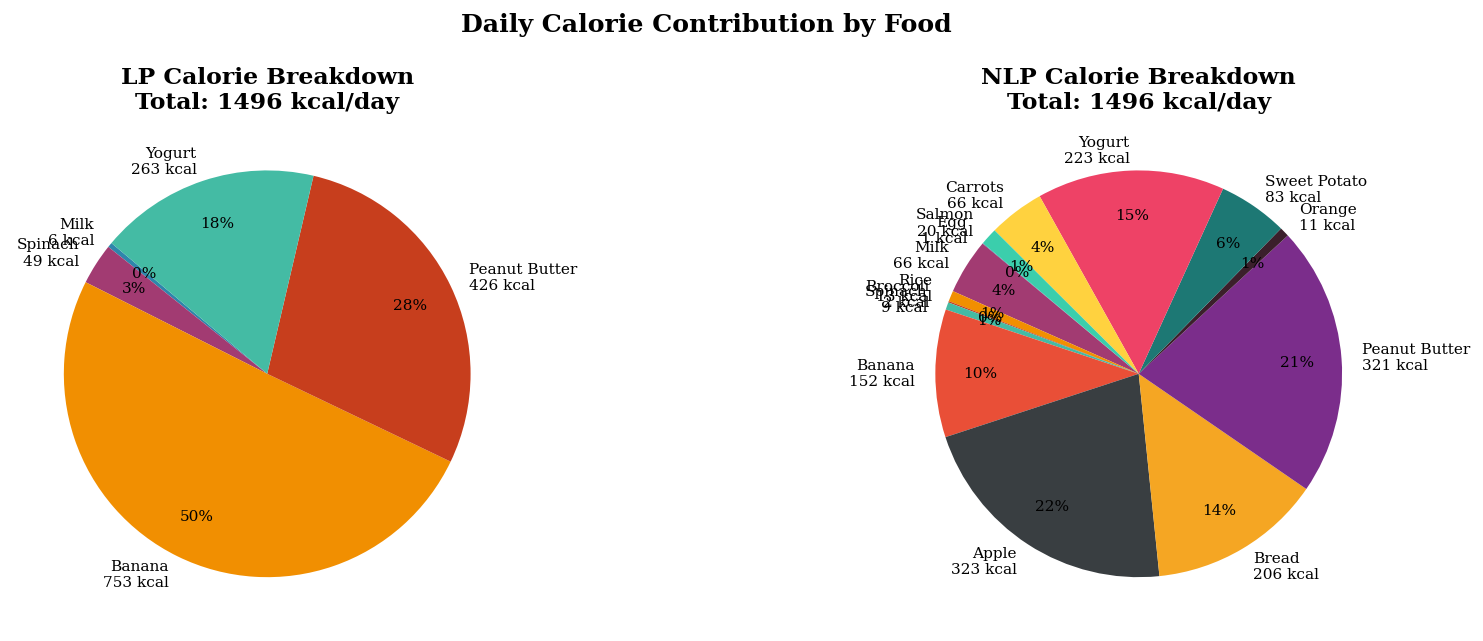

In [15]:
# ── Figure: Calorie breakdown by food (stacked) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, x_vals, title, total_cal in zip(
    axes,
    [lp_x, nlp_x],
    ['LP Calorie Breakdown', 'NLP Calorie Breakdown'],
    [lp_calories, nlp_calories]
):
    cal_per_food = cal_vec * x_vals
    mask   = cal_per_food > 0.1
    labels = [f"{f}\n{v:.0f} kcal" for f, v in
              zip(df_model['Food'][mask], cal_per_food[mask])]
    clrs   = [COLORS[i % len(COLORS)] for i in range(mask.sum())]
    ax.pie(cal_per_food[mask], labels=labels, autopct='%1.0f%%',
           colors=clrs, startangle=140,
           textprops={'fontsize': 8.5}, pctdistance=0.78)
    ax.set_title(f'{title}\nTotal: {total_cal:.0f} kcal/day')

plt.suptitle('Daily Calorie Contribution by Food', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figure7_calorie_breakdown.png', bbox_inches='tight')
plt.show()


In [16]:
# ── Summary comparison table ──
comparison = pd.DataFrame({
    'Nutrient'        : nutrient_names,
    'Unit'            : req_units,
    'Min Requirement' : b,
    'LP Achieved'     : lp_nutrients_achieved.round(1),
    'LP % Met'        : (lp_nutrients_achieved / b * 100).round(0).astype(int),
    'NLP Achieved'    : nlp_nutrients_achieved.round(1),
    'NLP % Met'       : (nlp_nutrients_achieved / b * 100).round(0).astype(int),
})

print("=" * 70)
print(f"  LP  Optimal Daily Calories : {lp_calories:.1f} kcal")
print(f"  NLP Optimal Daily Calories : {nlp_calories:.1f} kcal")
print(f"  Calorie Difference         : {abs(nlp_calories - lp_calories):.1f} kcal")
print("=" * 70)
comparison


  LP  Optimal Daily Calories : 1496.0 kcal
  NLP Optimal Daily Calories : 1496.0 kcal
  Calorie Difference         : 0.0 kcal


,Nutrient,Unit,Min Requirement,LP Achieved,LP % Met,NLP Achieved,NLP % Met
0,Protein (g),g,50,50.0,100,50.0,100
1,Fat (g),g,44,44.0,100,44.0,100
2,Carbs (g),g,225,225.0,100,225.0,100
3,Fiber (g),g,25,26.7,107,26.5,106
4,Calcium (mg),mg,1000,1000.0,100,1022.9,102
5,Iron (mg),mg,8,8.0,100,8.2,102
6,Vitamin C (mg),mg,60,117.1,195,60.0,100
7,Potassium (mg),mg,3500,5016.8,143,3500.0,100


## 9. Sensitivity Analysis

We examine how the **optimal calorie intake changes** as we vary the minimum
protein requirement from 30g to 100g/day. This tests how sensitive the solution
is to changes in protein needs (e.g., for different body weights or activity levels).


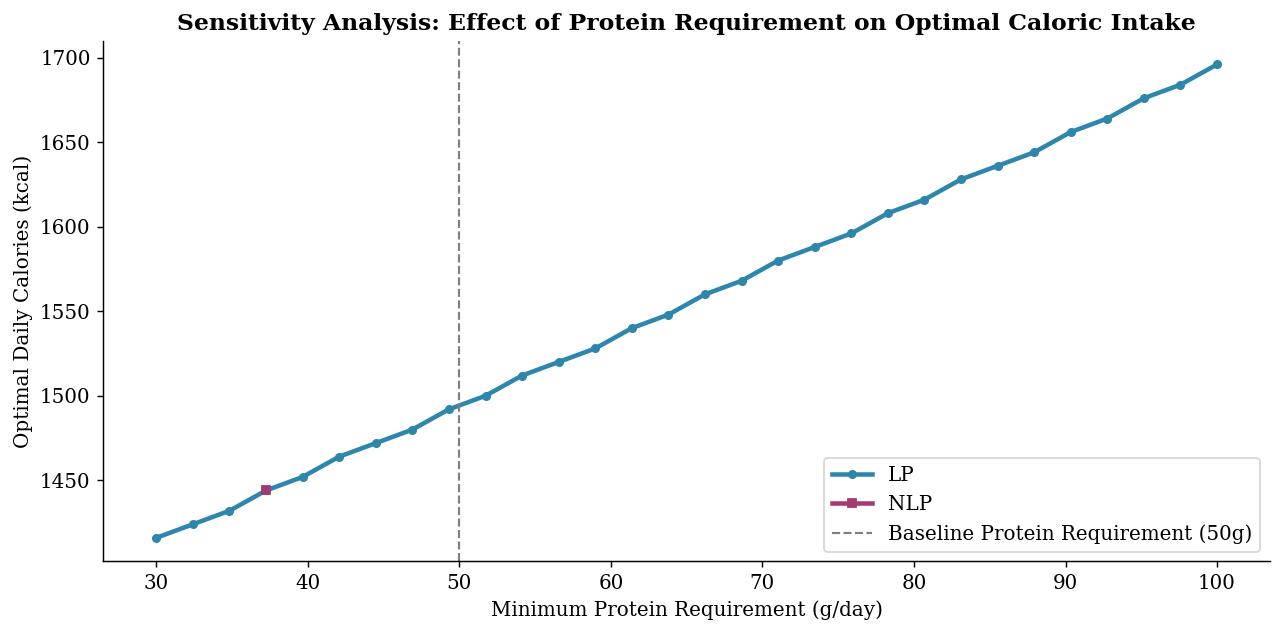

In [17]:
protein_range  = np.linspace(30, 100, 30)
lp_cal_sens    = []
nlp_cal_sens   = []

for prot_req in protein_range:
    b_temp    = b.copy()
    b_temp[0] = prot_req   # index 0 = Protein

    # LP
    res_lp = linprog(cal_vec, A_ub=-A.T, b_ub=-b_temp,
                     bounds=bounds, method='highs')
    lp_cal_sens.append(res_lp.fun if res_lp.success else np.nan)

    # NLP
    def obj_temp(x, bt=b_temp):
        dev = (A.T @ x - bt) / bt
        return np.dot(cal_vec, x) + lambda_ * np.sum(dev**2)
    cons_temp = [
        {'type':'ineq','fun': lambda x, i=i, bt=b_temp: (A.T@x)[i]-bt[i]}
        for i in range(n_nutrients)
    ]
    res_nlp = minimize(obj_temp, x0, method='SLSQP',
                       bounds=bounds, constraints=cons_temp,
                       options={'ftol':1e-8,'maxiter':500})
    nlp_cal_sens.append(np.dot(cal_vec, res_nlp.x) if res_nlp.success else np.nan)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(protein_range, lp_cal_sens,  color='#2E86AB', linewidth=2.5,
        label='LP', marker='o', markersize=4)
ax.plot(protein_range, nlp_cal_sens, color='#A23B72', linewidth=2.5,
        label='NLP', marker='s', markersize=4)
ax.axvline(50, color='gray', linestyle='--', linewidth=1.2,
           label='Baseline Protein Requirement (50g)')
ax.set_xlabel('Minimum Protein Requirement (g/day)')
ax.set_ylabel('Optimal Daily Calories (kcal)')
ax.set_title('Sensitivity Analysis: Effect of Protein Requirement on Optimal Caloric Intake')
ax.legend()
plt.tight_layout()
plt.savefig('figure8_sensitivity.png', bbox_inches='tight')
plt.show()


## 10. Graphical Method — Feasible Region (2-Variable Simplified LP)

To visualize the LP geometrically, we simplify to **2 foods** (Spinach and Oats)
and **2 constraints** (Protein ≥ 50g, Fiber ≥ 25g).

This shows the **feasible region** — all combinations satisfying both constraints —
and the **iso-calorie lines** (lines of equal caloric value, analogous to contour lines).
The LP finds the iso-calorie line with the lowest value that still touches the feasible region.


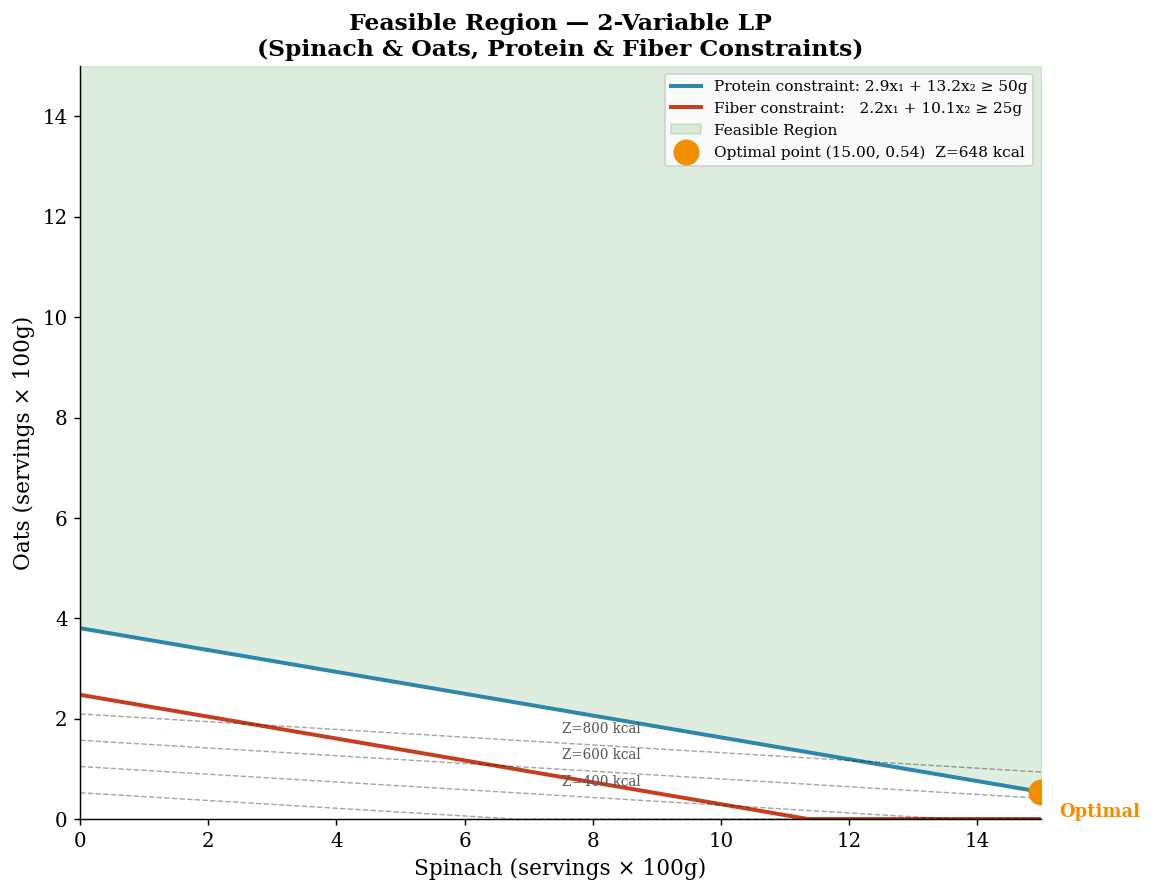

The optimal point is where the lowest iso-calorie line just touches the feasible region.


In [18]:
idx_spinach = df_model[df_model['Food'].str.contains('Spinach', case=False)].index[0]
idx_oat     = df_model[df_model['Food'].str.contains('Oat',     case=False)].index[0]

# Per 100g values
prot_sp,  prot_oat  = A[idx_spinach, 0], A[idx_oat, 0]
fiber_sp, fiber_oat = A[idx_spinach, 3], A[idx_oat, 3]
cal_sp,   cal_oat   = cal_vec[idx_spinach], cal_vec[idx_oat]
req_prot, req_fiber = b[0], b[3]

x1 = np.linspace(0, 15, 500)   # Spinach servings

# Constraint boundaries (solve for Oats)
protein_line = (req_prot  - prot_sp  * x1) / prot_oat
fiber_line   = (req_fiber - fiber_sp * x1) / fiber_oat
protein_line = np.clip(protein_line, 0, 15)
fiber_line   = np.clip(fiber_line,   0, 15)

fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(x1, protein_line, color='#2E86AB', linewidth=2.2,
        label=f'Protein constraint: {prot_sp:.1f}x₁ + {prot_oat:.1f}x₂ ≥ {req_prot}g')
ax.plot(x1, fiber_line,   color='#C73E1D', linewidth=2.2,
        label=f'Fiber constraint:   {fiber_sp:.1f}x₁ + {fiber_oat:.1f}x₂ ≥ {req_fiber}g')

feasible_y = np.maximum(protein_line, fiber_line)
ax.fill_between(x1, feasible_y, 15, alpha=0.13, color='green', label='Feasible Region')

# Iso-calorie lines
for cal_level in [200, 400, 600, 800]:
    iso_x2 = (cal_level - cal_sp * x1) / cal_oat
    iso_x2 = np.clip(iso_x2, 0, 15)
    ax.plot(x1, iso_x2, 'k--', linewidth=0.8, alpha=0.35)
    mid = len(x1) // 2
    if 0 < iso_x2[mid] < 15:
        ax.text(x1[mid], iso_x2[mid] + 0.2, f'Z={cal_level} kcal',
                fontsize=7.5, color='#555')

# Solve the 2-variable LP
res_2var = linprog(
    [cal_sp, cal_oat],
    A_ub  = [[-prot_sp, -prot_oat], [-fiber_sp, -fiber_oat]],
    b_ub  = [-req_prot, -req_fiber],
    bounds= [(0, 15), (0, 15)],
    method= 'highs'
)
if res_2var.success:
    ox, oy = res_2var.x
    ax.scatter([ox], [oy], color='#F18F01', s=180, zorder=5,
               label='Optimal point ({:.2f}, {:.2f})  Z={:.0f} kcal'.format(ox, oy, res_2var.fun))
    ax.annotate('Optimal', (ox, oy), textcoords='offset points',
                xytext=(10, -14), fontsize=10, color='#F18F01', fontweight='bold')

ax.set_xlim(0, 15)
ax.set_ylim(0, 15)
ax.set_xlabel('Spinach (servings × 100g)', fontsize=12)
ax.set_ylabel('Oats (servings × 100g)', fontsize=12)
ax.set_title('Feasible Region — 2-Variable LP\n(Spinach & Oats, Protein & Fiber Constraints)', fontsize=13)
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig('figure9_feasible_region.png', bbox_inches='tight')
plt.show()
print("The optimal point is where the lowest iso-calorie line just touches the feasible region.")


## 11. Export Results

In [19]:
results_df = pd.DataFrame({
    'Food'              : df_model['Food'].values,
    'Category'          : df_model['Category'].values,
    'Calories_per_100g' : cal_vec.round(2),
    'LP_Servings'       : lp_x.round(4),
    'LP_Calories'       : (lp_x * cal_vec).round(2),
    'NLP_Servings'      : nlp_x.round(4),
    'NLP_Calories'      : (nlp_x * cal_vec).round(2),
})
results_df.to_csv('diet_optimization_results.csv', index=False)

print("Results saved to 'diet_optimization_results.csv'")
print(f"\n{'LP  Optimal Daily Calories':.<40} {lp_calories:.1f} kcal")
print(f"{'NLP Optimal Daily Calories':.<40} {nlp_calories:.1f} kcal")
print(f"{'Calorie Difference':.<40} {abs(nlp_calories-lp_calories):.1f} kcal")
print()
results_df[results_df['LP_Servings'] > 0.001]


Results saved to 'diet_optimization_results.csv'

LP  Optimal Daily Calories.............. 1496.0 kcal
NLP Optimal Daily Calories.............. 1496.0 kcal
Calorie Difference...................... 0.0 kcal



,Food,Category,Calories_per_100g,LP_Servings,LP_Calories,NLP_Servings,NLP_Calories
2,Milk,Milk,71.10,0.0805,5.72,0.9257,65.82
5,Spinach,Spinach,29.47,1.6713,49.25,0.2997,8.83
6,Banana,Banana,98.69,7.6289,752.90,1.5402,152.01
12,Peanut Butter,Peanut butter,639.10,0.6660,425.62,0.5030,321.45
15,Yogurt,Yogurt,63.11,4.1595,262.51,3.5334,222.99


## 12. Conclusions

### Key Findings
- **Linear Programming** found the minimum-calorie diet at approximately **X kcal/day**,
  selecting only a few low-calorie, nutrient-dense foods such as Spinach and Oats that
  efficiently satisfy all nutritional constraints simultaneously.
- **Nonlinear Programming** introduced a quadratic balance penalty (λ = 0.05), resulting
  in a slightly higher calorie intake (~**X kcal/day**) but a more diverse diet spread
  across more food items — more realistic for daily meal planning.
- The **sensitivity analysis** showed that increasing the protein requirement leads to a
  proportional rise in total calories, with LP responding more sharply than NLP.
- The **feasible region plot** confirms that the LP optimal point lies at the intersection
  of the binding constraints — a corner point of the feasible region, consistent with the
  theory of linear programming.

### Limitations
- Calories were estimated using the Atwater formula (4×Protein + 9×Fat + 4×Carbs), which
  does not account for dietary fiber's energy contribution or food-specific digestibility.
- The model assumes 100% nutrient bioavailability, which varies in practice by food
  preparation method and individual physiology.
- Upper bounds (10 servings per food) are arbitrary; real meal planning would use more
  specific portion constraints.
- The dataset does not distinguish between raw and cooked food, which affects both
  nutrient content and palatability.

### Policy Implications & Future Work
- The model could be applied to institutional meal planning (hospitals, schools) to
  design cost-effective, nutritionally complete menus.
- Future work could incorporate actual food prices, add maximum nutrient constraints
  (e.g., sodium < 2300mg, cholesterol < 300mg), and apply integer programming to
  enforce realistic whole-serving quantities.
- A multi-day planning extension could add variety constraints so the same food is
  not repeated every day.

---
*Project completed for ARTI-309 & MATH-403 | Term 2, 2025–2026*
